<a href="https://colab.research.google.com/github/Shah4l/deep-learning-projects/blob/main/CNN_3_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout,Conv2D,MaxPooling2D
from tensorflow.keras.optimizers import Adam

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
classes={0:0
        ,1:1,
         2:2,
         3:3,
         4:4,
         5:5,
         6:6,
         7:7,
         8:8,
         9:9}

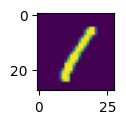

In [ ]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[3])

In [ ]:
int(y_train[3])

1

In [ ]:
classes[int(y_train[3])]

1

In [ ]:
x_train,x_test=x_train/255.0,x_test/255.0

In [ ]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [ ]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 37ms/step - accuracy: 0.8966 - loss: 0.3270 - val_accuracy: 0.9834 - val_loss: 0.0515
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 32ms/step - accuracy: 0.9853 - loss: 0.0492 - val_accuracy: 0.9860 - val_loss: 0.0412
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9898 - loss: 0.0311 - val_accuracy: 0.9885 - val_loss: 0.0341
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9921 - loss: 0.0248 - val_accuracy: 0.9897 - val_loss: 0.0314
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9935 - loss: 0.0203 - val_accuracy: 0.9881 - val_loss: 0.0411


In [ ]:
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)
print(f"Test Accuracy:{test_acc}")

313/313 - 3s - 9ms/step - accuracy: 0.9881 - loss: 0.0411
Test Accuracy:0.988099992275238


In [ ]:
import numpy as np
def predict(index):
  plt.imshow(x_test[index])
  pred_image=x_test[index].reshape(1,28,28,1)
  pred_prob=model.predict(pred_image)
  pred_class=np.argmax(pred_prob,axis=1)
  # Access the scalar value from the array
  pred_label=classes[int(pred_class[0])]
  print('Original label:',classes[int(y_test[index])])
  print('Predicted labe',pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Original label: 3
Predicted labe 3


/tmp/ipython-input-3335069508.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label=classes[int(pred_class)]


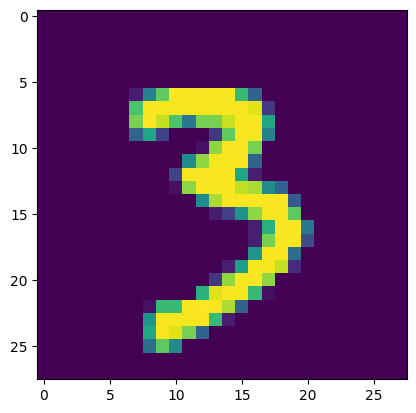

In [ ]:
predict(30)